In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="deep")
%matplotlib inline

In [2]:
# Combined summary data (from your runs)
data = {
    'config': ['No Guardrail', 'Low (v4)', 'Medium (v3)'] * 2,
    'model': ['Sonnet 4.5']*3 + ['Haiku 4.5']*3,
    'success_rate': [91.7, 16.7, 16.7, 100.0, 25.0, 25.0],
    'intervened_rate': [0.0, 100.0, 83.3, 0.0, 75.0, 75.0],
    'avg_latency_s': [2.085, 2.713, 2.426, 1.353, 1.533, 1.541],
    'avg_confidence': [0.964, 0.975, 0.975, 0.950, 0.950, 0.950],
    'avg_match_pct': [100.0, 100.0, 100.0, 100.0, 100.0, 100.0]
}

df_combined = pd.DataFrame(data)
display(df_combined.round(3))

,config,model,success_rate,intervened_rate,avg_latency_s,avg_confidence,avg_match_pct
0,No Guardrail,Sonnet 4.5,91.7,0.0,2.085,0.964,100.0
1,Low (v4),Sonnet 4.5,16.7,100.0,2.713,0.975,100.0
2,Medium (v3),Sonnet 4.5,16.7,83.3,2.426,0.975,100.0
3,No Guardrail,Haiku 4.5,100.0,0.0,1.353,0.950,100.0
4,Low (v4),Haiku 4.5,25.0,75.0,1.533,0.950,100.0
5,Medium (v3),Haiku 4.5,25.0,75.0,1.541,0.950,100.0


Saved: sonnet_vs_haiku_guardrail_comparison.png


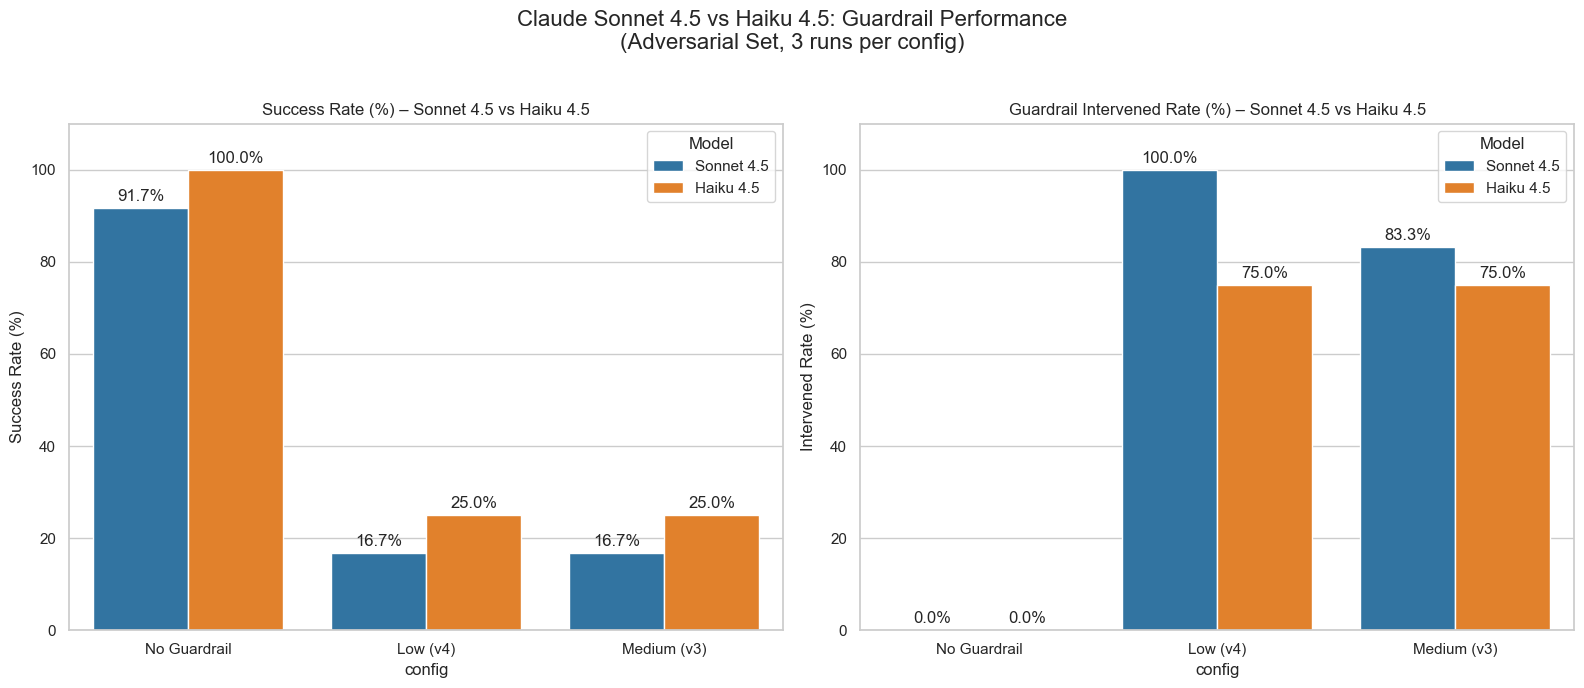

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# Success Rate
sns.barplot(
    data=df_combined,
    x='config',
    y='success_rate',
    hue='model',
    palette=['#1f77b4', '#ff7f0e'],  # blue for Sonnet, orange for Haiku
    ax=ax[0]
)
ax[0].set_title('Success Rate (%) – Sonnet 4.5 vs Haiku 4.5')
ax[0].set_ylabel('Success Rate (%)')
ax[0].set_ylim(0, 110)
ax[0].legend(title='Model', loc='upper right')

# Add value labels
for container in ax[0].containers:
    ax[0].bar_label(container, fmt='%.1f%%', padding=3)

# Intervened Rate
sns.barplot(
    data=df_combined,
    x='config',
    y='intervened_rate',
    hue='model',
    palette=['#1f77b4', '#ff7f0e'],
    ax=ax[1]
)
ax[1].set_title('Guardrail Intervened Rate (%) – Sonnet 4.5 vs Haiku 4.5')
ax[1].set_ylabel('Intervened Rate (%)')
ax[1].set_ylim(0, 110)
ax[1].legend(title='Model', loc='upper right')

for container in ax[1].containers:
    ax[1].bar_label(container, fmt='%.1f%%', padding=3)

plt.suptitle("Claude Sonnet 4.5 vs Haiku 4.5: Guardrail Performance\n(Adversarial Set, 3 runs per config)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('sonnet_vs_haiku_guardrail_comparison.png', dpi=200, bbox_inches='tight')
print("Saved: sonnet_vs_haiku_guardrail_comparison.png")
plt.show()

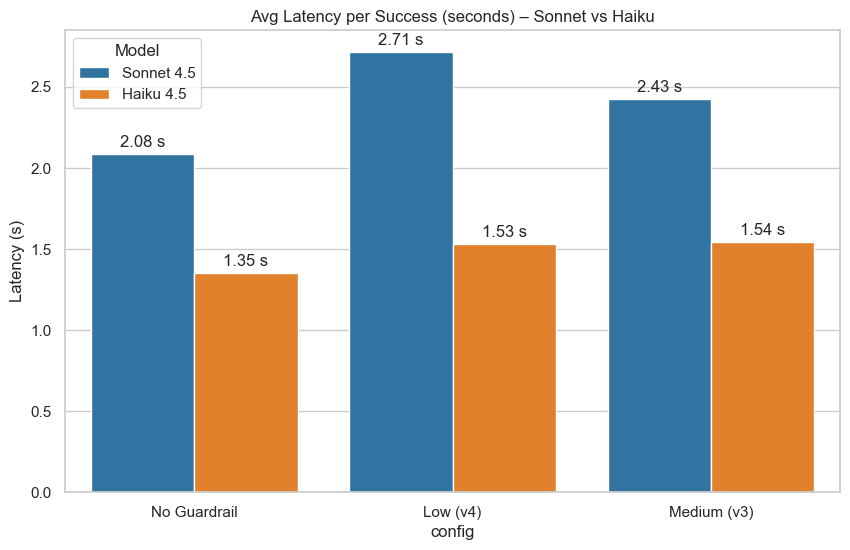

In [4]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_combined,
    x='config',
    y='avg_latency_s',
    hue='model',
    palette=['#1f77b4', '#ff7f0e']
)
plt.title('Avg Latency per Success (seconds) – Sonnet vs Haiku')
plt.ylabel('Latency (s)')
plt.legend(title='Model')
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.2f s', padding=3)
plt.savefig('sonnet_vs_haiku_latency.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Cost data — all lists must have the same length (4 rows)
cost_data = {
    'config': ['No Guardrail', 'No Guardrail', 'Guarded (avg Low/Med)', 'Guarded (avg Low/Med)'],
    'model': ['Sonnet 4.5', 'Haiku 4.5', 'Sonnet 4.5', 'Haiku 4.5'],
    'total_cost_sonnet_rates': [0.0464 * 3, 0.0464 * 3, 0.0122 * 3, 0.0122 * 3],          # Sonnet pricing applied to all
    'total_cost_haiku_real': [0.0464 * (1/3), 0.0464 * (1/3), 0.0122 * (1/3), 0.0122 * (1/3)]  # Haiku real pricing (~1/3)
}

df_cost = pd.DataFrame(cost_data)
df_cost['total_cost_sonnet_rates'] = df_cost['total_cost_sonnet_rates'].round(4)
df_cost['total_cost_haiku_real'] = df_cost['total_cost_haiku_real'].round(4)

display(df_cost)

,config,model,total_cost_sonnet_rates,total_cost_haiku_real
0,No Guardrail,Sonnet 4.5,0.1392,0.0155
1,No Guardrail,Haiku 4.5,0.1392,0.0155
2,Guarded (avg Low/Med),Sonnet 4.5,0.0366,0.0041
3,Guarded (avg Low/Med),Haiku 4.5,0.0366,0.0041


C:\Users\macon\AppData\Local\Temp\ipykernel_12256\2596892312.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\macon\AppData\Local\Temp\ipykernel_12256\2596892312.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Saved final versions with clear, bold labels on all bars


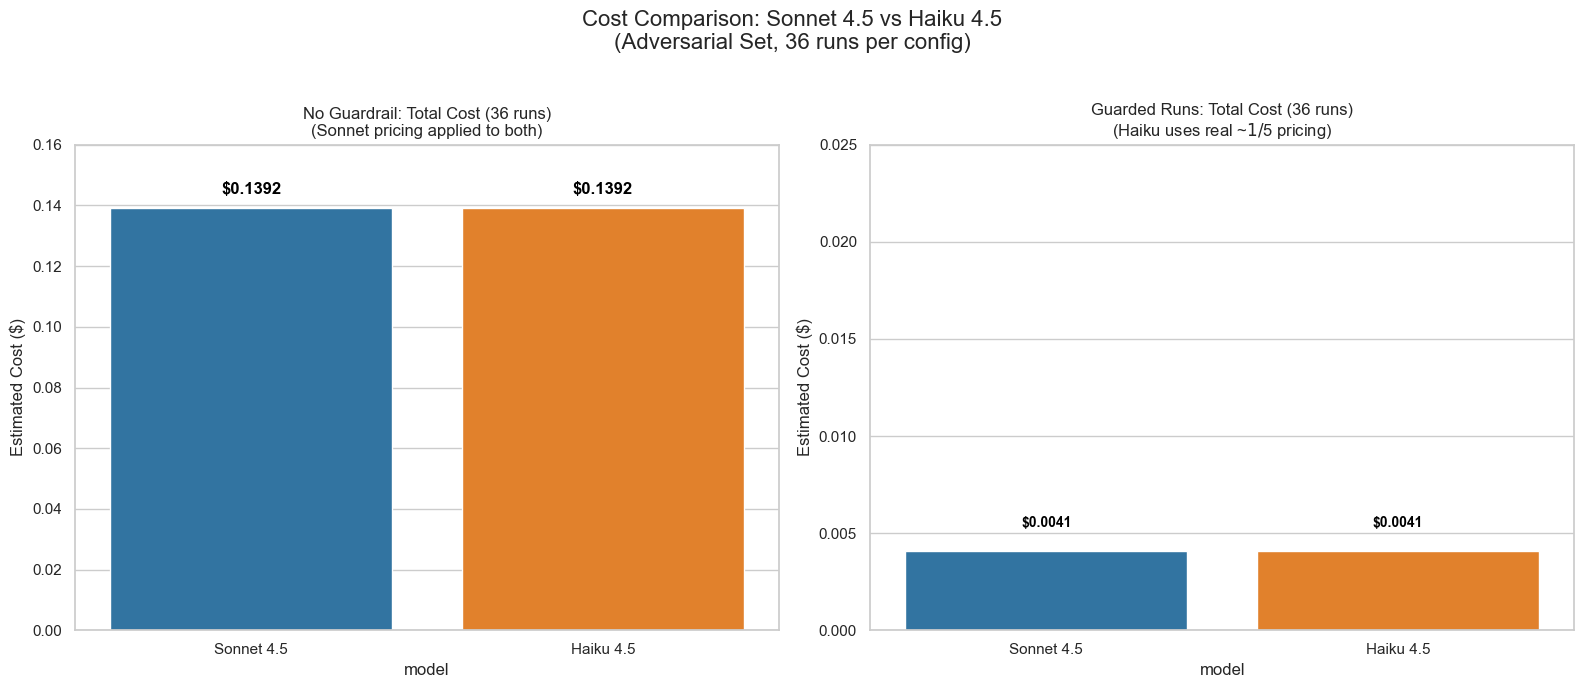

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(16, 7), sharey=False)

# Left: No Guardrail – use bar_label (tall bars)
sns.barplot(
    data=df_cost[df_cost['config'] == 'No Guardrail'],
    x='model',
    y='total_cost_sonnet_rates',
    ax=ax[0],
    palette=['#1f77b4', '#ff7f0e']
)
ax[0].set_title('No Guardrail: Total Cost (36 runs)\n(Sonnet pricing applied to both)')
ax[0].set_ylabel('Estimated Cost ($)')
ax[0].set_ylim(0, 0.16)

for container in ax[0].containers:
    ax[0].bar_label(
        container,
        fmt='$%.4f',
        padding=8,
        fontsize=12,
        fontweight='bold',
        color='black'
    )

# Right: Guarded – use annotate() for precise offset on tiny bars
sns.barplot(
    data=df_cost[df_cost['config'] == 'Guarded (avg Low/Med)'],
    x='model',
    y='total_cost_haiku_real',
    ax=ax[1],
    palette=['#1f77b4', '#ff7f0e']
)
ax[1].set_title('Guarded Runs: Total Cost (36 runs)\n(Haiku uses real ~$1/$5 pricing)')
ax[1].set_ylabel('Estimated Cost ($)')
ax[1].set_ylim(0, 0.025)  # Extra headroom

# Manual annotate for right plot – no overlap/clipping
for container in ax[1].containers:
    for rect in container:
        height = rect.get_height()
        label = f'${height:.4f}' if height > 0 else '$0.0000'
        ax[1].annotate(
            label,
            xy=(rect.get_x() + rect.get_width() / 2., height),
            xytext=(0, 15),                # vertical offset in points
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold',
            color='black'
        )

# Thin zero line for reference
ax[1].axhline(0, color='gray', linestyle='--', linewidth=0.5)

plt.suptitle("Cost Comparison: Sonnet 4.5 vs Haiku 4.5\n(Adversarial Set, 36 runs per config)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('cost_savings_no_gr.png', dpi=200, bbox_inches='tight')
plt.savefig('cost_savings_guarded.png', dpi=200, bbox_inches='tight')
print("Saved final versions with clear, bold labels on all bars")
plt.show()